In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

## Preprocessing

In [7]:
DATA_PATH = "/drive/MyDrive/updated_data.geojson"
df = gpd.read_file(DATA_PATH)

DataSourceError: /drive/MyDrive/updated_data.geojson: No such file or directory

In [ ]:
ecec_covariates = ["ecec_participation", "coverage", "public_coverage", "private_coverage", "per_capita_public_expenditure", 
                   "per_capita_user_contribution", "other_percapita_public_expenditure", "other_percapita_user_contrib",
                   "other_per_capita_expenditure", "ecec_diffusion"]
    
categorical_cols = ["prov_name", "urban_type"]

target = "fem_empl_rate"
offset = "wr_men"

In [ ]:
to_drop = ecec_covariates + categorical_cols + [target] + [offset]
df_variables = df.drop(columns=to_drop)

n_obs, n_feat = df_variables.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


Number of observations: 107, number of predictors: 37


## Correlation Based Selection

In [ ]:
corr_matrix = df_variables.corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.85

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [ ]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
              var1                   var2   corr
         empl_rate             inact_rate -0.989
net_migration_rate adj_net_migration_rate  0.985
         part_rate             inact_rate -0.978
         part_rate              empl_rate  0.973
      fem_edu_rate          male_edu_rate  0.952
        inact_rate               empl_gap -0.921
       unempl_rate              empl_rate -0.918
         empl_rate               empl_gap  0.917
         empl_rate             young_neet -0.900
         part_rate               empl_gap  0.892
        inact_rate             young_neet  0.882
         part_rate             young_neet -0.876
        inact_rate     net_migration_rate -0.873
    fertility_rate           ageing_index -0.873
         empl_rate     net_migration_rate  0.866
       unempl_rate             young_neet  0.858
       unempl_rate             inact_rate  0.852
   dependency_rate           ageing_index  0.852


In [ ]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(empl_rate, 6)
(inact_rate, 6)
(part_rate, 4)
(young_neet, 4)
(net_migration_rate, 3)
(empl_gap, 3)
(unempl_rate, 3)
(ageing_index, 2)
(fem_edu_rate, 1)
(adj_net_migration_rate, 1)
(dependency_rate, 1)
(fertility_rate, 1)
(male_edu_rate, 1)


In [ ]:
to_drop = ["empl_rate", "part_rate", "adj_net_migration_rate", "male_edu_rate", "empl_gap", "inact_rate", "ageing_index", "unempl_rate"]
df_reduced = df_variables.drop(columns=to_drop)

## Bayesian Lasso

In [ ]:
selected_covariates = list(df_reduced.columns)

X = df[selected_covariates].to_numpy()
offset = df[offset].to_numpy()
y = df[target].to_numpy()

X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

y = y / 100
y_star = np.log(y / (1 - y))

offset = offset / 100
logit_offset = np.log(offset / (1 - offset))

n_obs, n_feat = X_star.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")



Number of observations: 107, number of predictors: 29


In [ ]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_star)
    y_data = pm.Data("y_data", y_star)
    #offset = pm.Data("offset", logit_offset)

    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0) 
    lambda_ = pm.Deterministic("lambda", pm.math.sqrt(lambda_sq))

    sigma = pm.HalfNormal("sigma", sigma=1.0)

    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)
    
    mu = pm.math.dot(X_data, beta) + intercept #+ offset

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
/home/luca/Projects/Bayesian-Statistics-Project/.venv/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [lambda_sq, sigma, beta, alpha]


Output()

In [ ]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta_95.index = selected_covariates

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_2.5%"] <= 0) &
    (summary_beta_95["hdi_97.5%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

selected_covariates_df = summary_beta_95[~summary_beta_95["contains_zero"]].index.tolist()

                           mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate           -0.297    -0.375     -0.222          False
n_members_family         -0.100    -0.150     -0.045          False
net_migration_rate       -0.092    -0.163     -0.024          False
avg_children_per_woman   -0.071    -0.133     -0.006          False
fertility_rate           -0.067    -0.152      0.014           True
fem_maj_empl_rate         0.040     0.010      0.072          False
fem_edu_rate             -0.029    -0.067      0.011           True
advanced_business_empl   -0.029    -0.091      0.032           True
first_birth_maternal_age  0.024    -0.016      0.067           True
eco_urban_index           0.021    -0.008      0.052           True
service_empl_rate         0.018    -0.014      0.054           True
area_km2                 -0.017    -0.044      0.008           True
n_large_comp             -0.014    -0.061      0.027           True
startup_ratio             0.010    -0.019      0

In [ ]:
print(selected_covariates_df)

['fem_house_rate', 'n_members_family', 'net_migration_rate', 'avg_children_per_woman', 'fem_maj_empl_rate']


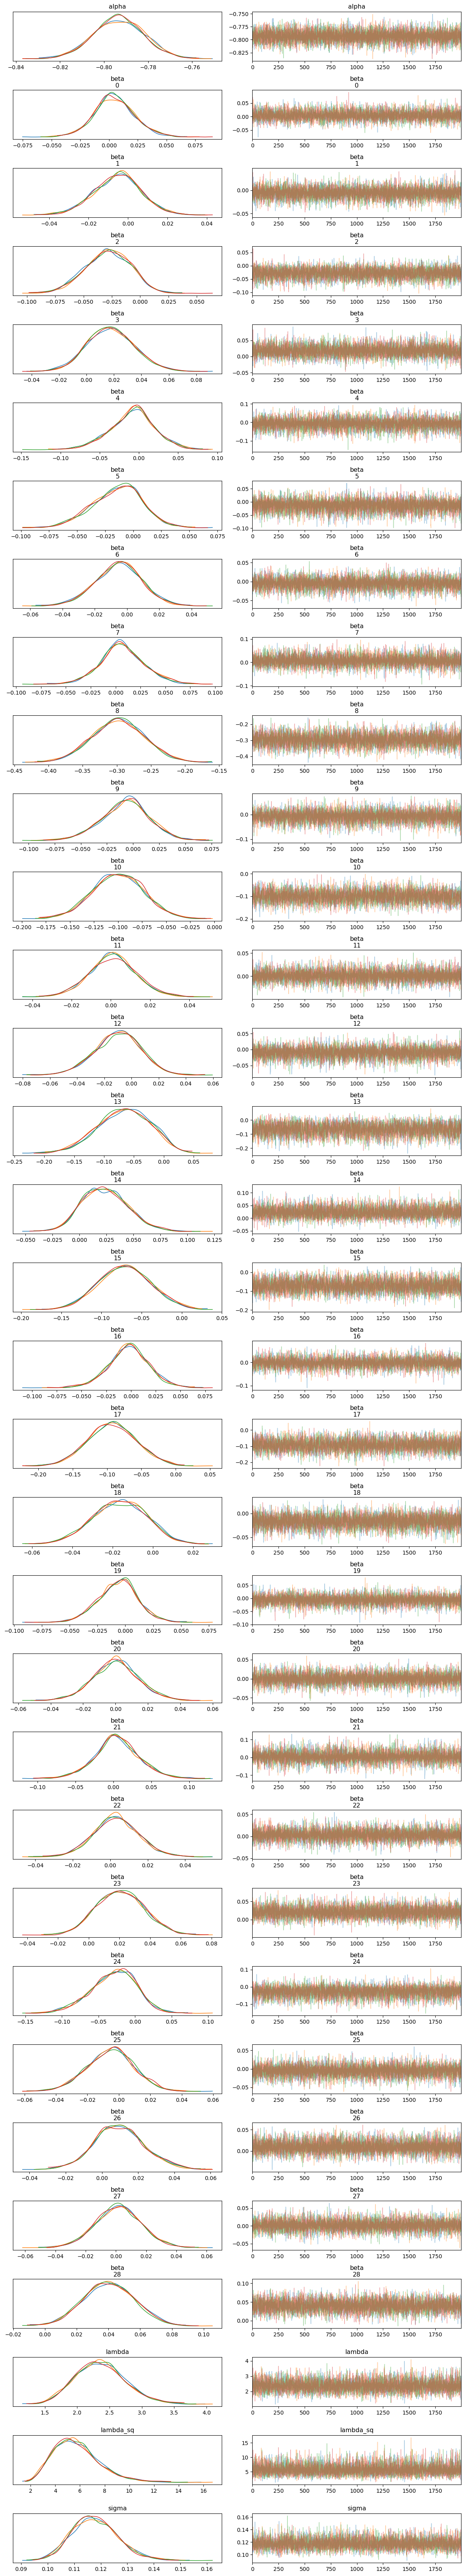

In [ ]:
az.rcParams["plot.max_subplots"] = 100   
az.plot_trace(trace, compact=False)
plt.tight_layout()

# az.plot_trace(trace)
# plt.tight_layout()

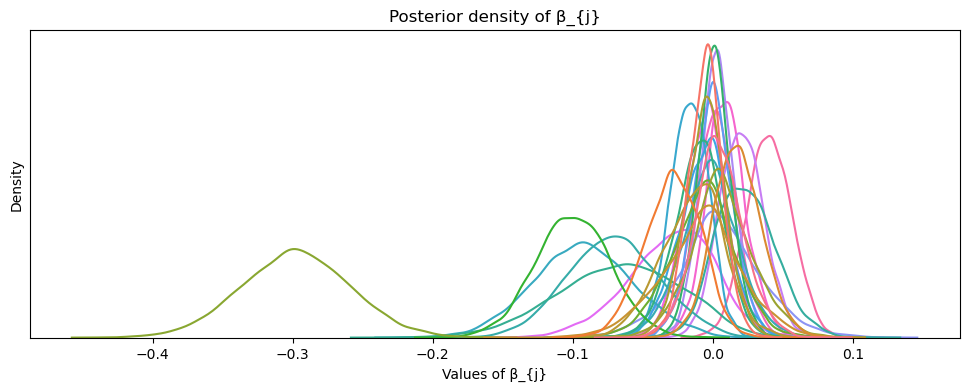

In [ ]:
beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))
sns.kdeplot(beta_samples.T, legend=False)

plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()

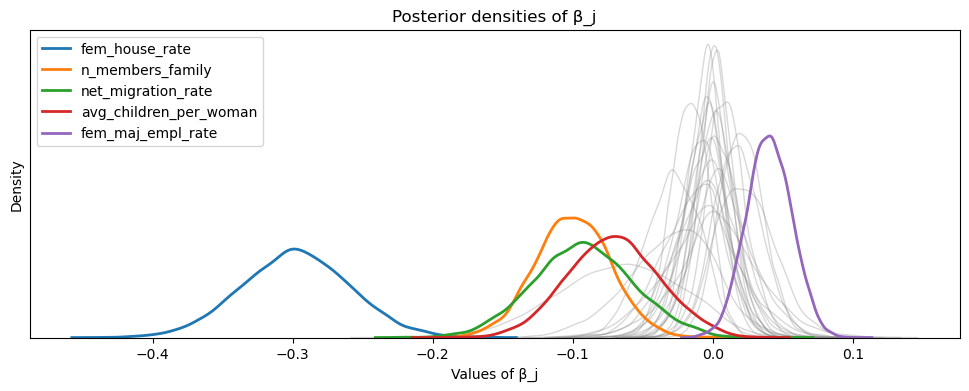

In [ ]:
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values  
if beta_raw.shape[0] == len(selected_covariates):
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T  

n_feat = len(selected_covariates)

plt.figure(figsize=(12, 4))

for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

for name in summary_beta_95.index[~summary_beta_95["contains_zero"]]:
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()

## ECEC Covariates Correlation

In [ ]:
df_ecec = df[ecec_covariates]
df_ecec = df_ecec.drop(columns=["private_coverage"])

In [ ]:
len(ecec_covariates)

10

In [ ]:
corr_matrix = df[df_ecec.columns].corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.75

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [ ]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
                              var1                          var2   corr
other_percapita_public_expenditure  other_per_capita_expenditure  0.995
                ecec_participation per_capita_public_expenditure  0.825
     per_capita_public_expenditure  per_capita_user_contribution  0.790
                ecec_participation  per_capita_user_contribution  0.788


In [ ]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(ecec_participation, 2)
(per_capita_user_contribution, 2)
(per_capita_public_expenditure, 2)
(other_percapita_public_expenditure, 1)
(other_per_capita_expenditure, 1)


In [ ]:
ecec_to_drop = ["other_per_capita_expenditure", "per_capita_user_contribution", "ecec_participation"]

df_ecec = df_ecec.drop(columns=ecec_to_drop)

ecec_selected = list(df_ecec.columns)

## Results

In [ ]:
final_covariates = selected_covariates_df + ecec_selected
print(f"{len(final_covariates)} selected covariates:")
print(final_covariates)

11 selected covariates:
['fem_house_rate', 'n_members_family', 'net_migration_rate', 'avg_children_per_woman', 'fem_maj_empl_rate', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']


In [ ]:
freq_lasso_selection = ["coverage", "ecec_diffusion", "per_capita_public_expenditure", "ecec_participation", "per_capita_user_contribution", "ageing_index", "service_empl_rate", "n_members_family", "avg_children_per_woman", "fem_house_rate"]

In [ ]:
all_covariates = (set(final_covariates) | set(freq_lasso_selection))

# Build and print the table
print(f"{'covariate':40s} | {'in_final_covariates':20s} | {'in_freq_lasso':15s}")
print("-" * 85)

for cov in all_covariates:
    in_final = cov in final_covariates
    in_freq  = cov in freq_lasso_selection
    print(f"{cov:40s} | {str(in_final):20s} | {str(in_freq):15s}")

covariate                                | in_final_covariates  | in_freq_lasso  
-------------------------------------------------------------------------------------
service_empl_rate                        | False                | True           
other_percapita_user_contrib             | True                 | False          
coverage                                 | True                 | True           
public_coverage                          | True                 | False          
net_migration_rate                       | True                 | False          
fem_house_rate                           | True                 | True           
ecec_diffusion                           | True                 | True           
fem_maj_empl_rate                        | True                 | False          
ecec_participation                       | False                | True           
per_capita_user_contribution             | False                | True           
n_members_fa